# Fitting the models and additional control of `fit_gam` in tradeSeq-python

Python port of the R vignette `vignettes/fitGAM.Rmd`. The companion
`tradeSeq.ipynb` walks through the analysis workflow; this notebook
focuses on the **mechanics of fitting** — knot selection, covariates,
parallelism, gene subsetting, list-mode output, and convergence.


# Introduction

`tradeSeq` fits gene-wise negative-binomial generalized additive models
along trajectories and performs inference through contrasts of fitted
GAM parameters. This Python notebook follows the R `fitGAM` vignette but
uses only AnnData slots; the R container and trajectory accessor calls
collapse to direct reads from the bundled h5ad fixture.


## Installation

```bash
pip install tradeSeq-python
```


## Load data

In [1]:
import numpy as np
import pandas as pd
from IPython.display import Image, display

import ggplot2_py as g
from patchwork._display import gtable_to_png
from patchwork.core import patchworkGrob

import tradeseq as ts


def show_plot(plot, *, width, height):
    plot.fig_width = width
    plot.fig_height = height
    display(plot)


def show_patchwork(plot, *, width, height, dpi=150):
    png = gtable_to_png(patchworkGrob(plot), width=width, height=height, dpi=dpi)
    display(Image(data=png, format='png'))


adata = ts.load_paul15()
adata


AnnData object with n_obs × n_vars = 2660 × 240
    obs: 'cluster', 'celltype'
    uns: 'provenance', 'slingshot'
    obsm: 'X_umap', 'cell_weights', 'pseudotime'
    layers: 'counts'

We find two lineages for this dataset. The trajectory can be visualized
with `plot_gene_count`, using cell type labels to colour the cells:


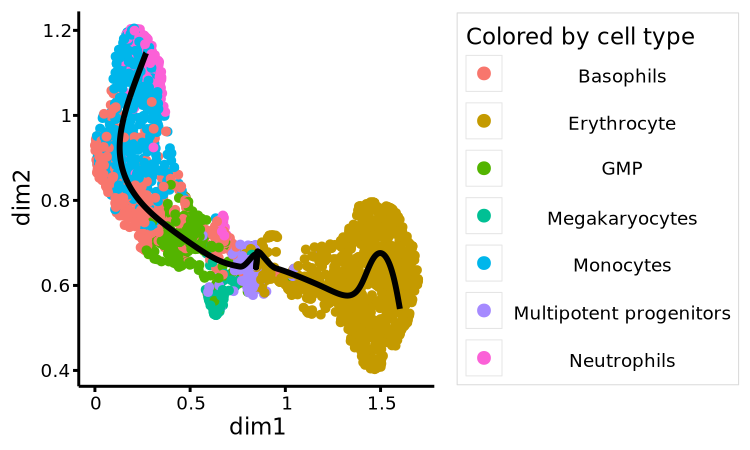

In [2]:
show_plot(
    ts.plot_gene_count(adata, clusters_key='celltype', title='Colored by cell type'),
    width=5,
    height=3,
)


# Choosing K: a deeper dive into the output from `evaluate_k`

`evaluate_k` refits an NB-GAM at each candidate knot count, recording
the per-gene AIC. The R version produces a 4-panel diagnostic figure
via `par(mfrow = c(1, 4))`; the Python version composes the same four
panels with `patchwork.wrap_plots(..., nrow=1)`.


### Downstream of any trajectory-inference method

In [3]:
aic_mat = ts.evaluate_k(
    adata,
    k_range=range(3, 8),  # try k = 3 ... 7
    n_genes=100,
    plot=False,
    random_state=5,
)
aic_mat.shape


evaluate_k k=3:   0%|          | 0/100 [00:00<?, ?it/s]

evaluate_k k=4:   0%|          | 0/100 [00:00<?, ?it/s]

evaluate_k k=5:   0%|          | 0/100 [00:00<?, ?it/s]

evaluate_k k=6:   0%|          | 0/100 [00:00<?, ?it/s]

evaluate_k k=7:   0%|          | 0/100 [00:00<?, ?it/s]

(100, 5)

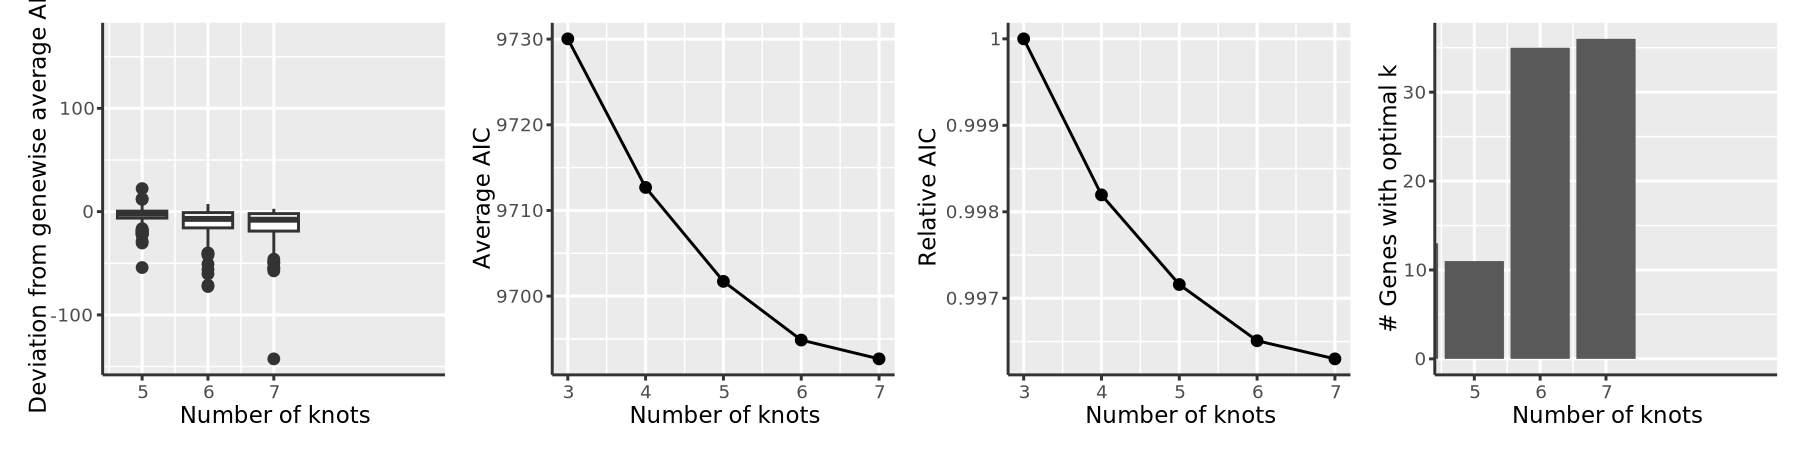

In [4]:
diag_plot = ts.plot_evaluatek_results(aic_mat, k_range=range(3, 8))
diag_plot


The R vignette interprets these panels as follows (the same
interpretation applies here):

1. **Boxplot** — per-gene AIC deviations from the average across `k`.
2. **Mean AIC** — should plateau around an optimal `k`.
3. **Mean relative AIC** — the elbow indicates the optimal `k`.
4. **Optimal-k histogram** — distribution of per-gene optimal knot
   counts (the mode is the recommended choice).


# Fit additive models

The full fit. Following the R vignette, we fit all 240 genes in the
bundled Paul15 dataset.


In [5]:
# For reproducibility.
rng = np.random.default_rng(7)
probs = adata.obsm['cell_weights'] / adata.obsm['cell_weights'].sum(axis=1, keepdims=True)
w_samp = np.zeros_like(adata.obsm['cell_weights'], dtype=np.int64)
for i in range(adata.n_obs):
    w_samp[i] = rng.multinomial(1, probs[i])

a = adata.copy()
ts.fit_gam(a, n_knots=6, verbose=False, _w_samp=w_samp)
a


AnnData object with n_obs × n_vars = 2660 × 240
    obs: 'cluster', 'celltype'
    var: 'tradeseq_converged'
    uns: 'provenance', 'slingshot', 'tradeseq'
    obsm: 'X_umap', 'cell_weights', 'pseudotime'
    varm: 'tradeseq_beta', 'tradeseq_Sigma'
    layers: 'counts'

Inspect the convergence flag — R uses `try(withCallingHandlers(...))`
to catch BOTH errors AND warnings; Python mirrors that via
`warnings.catch_warnings(record=True)`. Either kind of issue marks the
gene as `converged=False`.


In [6]:
a.var['tradeseq_converged'].value_counts()


tradeseq_converged
True    240
Name: count, dtype: int64

## Adding covariates to the model

You can include extra fixed effects via the `U` argument (the design
matrix of fixed effects, `(n_cells, k)`). The R vignette constructs an
intercept plus an artificial two-batch factor with `model.matrix(~batch)`;
the code below uses the equivalent numeric design matrix.


In [7]:
batch = np.repeat([0.0, 1.0], repeats=a.n_obs // 2)
if batch.size < a.n_obs:
    batch = np.concatenate([batch, [1.0]])
U = np.column_stack([np.ones(a.n_obs), batch])
sce_batch = ts.fit_gam(
    a.copy(),
    U=U,
    n_knots=6,
    verbose=False,
    _w_samp=w_samp,
    copy=True,
)
sce_batch


AnnData object with n_obs × n_vars = 2660 × 240
    obs: 'cluster', 'celltype'
    var: 'tradeseq_converged'
    uns: 'provenance', 'slingshot', 'tradeseq'
    obsm: 'X_umap', 'cell_weights', 'pseudotime'
    varm: 'tradeseq_beta', 'tradeseq_Sigma'
    layers: 'counts'

## Parallel computing

Set `parallel=True` (and `n_jobs > 1`) to dispatch per-gene fits via
joblib (R uses `BiocParallel::bplapply`):


In [8]:
sce_parallel = ts.fit_gam(
    a.copy(), parallel=True, n_jobs=2, n_knots=6,
    verbose=False, _w_samp=w_samp, copy=True,
)
sce_parallel


AnnData object with n_obs × n_vars = 2660 × 240
    obs: 'cluster', 'celltype'
    var: 'tradeseq_converged'
    uns: 'provenance', 'slingshot', 'tradeseq'
    obsm: 'X_umap', 'cell_weights', 'pseudotime'
    varm: 'tradeseq_beta', 'tradeseq_Sigma'
    layers: 'counts'

## Fitting only a subset of genes

Pass `genes=` (a list of gene names or integer indices). Library size
and TMM normalisation use ALL genes — only the smoothers are
restricted.


In [9]:
sce25 = ts.fit_gam(
    a.copy(), genes=list(a.var_names[:25]),
    n_knots=6, verbose=False, _w_samp=w_samp, copy=True,
)
sce25.var['tradeseq_converged'].head(30)


gene
Acin1        True
Actb         True
Ak2          True
Alad         True
Alas1        True
Aldoa        True
Anapc5       True
Ankrd13a     True
Anp32b       True
Apoe         True
Aqp1         True
Arhgdia      True
Arhgdib      True
Arpc2        True
Atf4         True
Atp1b2       True
Atp5a1       True
Atp5b        True
Atp5d        True
Atp5f1       True
Atp5g3       True
Atp5o        True
Atpase6      True
Atpif1       True
Bag1         True
Banf1       False
Blvrb       False
Bsg         False
C1qbp       False
Calm1       False
Name: tradeseq_converged, dtype: bool

## Zero inflation

If you have ZINB observation weights (e.g. from a zero-inflation
decoupling step), pass them via `sample_weights` (shape `(n_genes,
n_cells)`). The weights enter the GLM as observation weights, exactly
as in the R source's `weights = weights[teller, ]` at
`fitGAM.R:261`.


In [10]:
# Stub example — weights all 1.0; in production use real ZINB output.
weights = np.ones((a.n_vars, a.n_obs))
zinb_fit = ts.fit_gam(
    a.copy(), sample_weights=weights, n_knots=6,
    verbose=False, _w_samp=w_samp, copy=True,
)
zinb_fit


AnnData object with n_obs × n_vars = 2660 × 240
    obs: 'cluster', 'celltype'
    var: 'tradeseq_converged'
    uns: 'provenance', 'slingshot', 'tradeseq'
    obsm: 'X_umap', 'cell_weights', 'pseudotime'
    varm: 'tradeseq_beta', 'tradeseq_Sigma'
    layers: 'counts'

## Convergence issues on small or zero-inflated datasets

Genes can fail to converge due to extreme sparsity. Inspect the
`tradeseq_converged` flag and consider raising knots, applying ZINB
weights, or excluding the offending genes.


In [11]:
failed = a.var.index[~a.var['tradeseq_converged']].tolist()
print(f'{len(failed)} of {a.n_vars} genes failed to converge.')


0 of 240 genes failed to converge.


## tradeSeq list output

Setting `sce=False` returns a `dict[gene_name, FittedGam]` instead of
mutating the AnnData. The `FittedGam` dataclass exposes the minimal
mgcv-`gam` attributes that the downstream exports consume:
`coef_`, `cov_`, `lpmatrix_`, `dm_`, `summary_s_table`, `alpha_`,
`converged_`. This mode is required by `get_smoother_pvalues` and
`get_smoother_test_stats`.


In [12]:
fits = ts.fit_gam(
    a, n_knots=6, verbose=False, _w_samp=w_samp, sce=False,
)
type(fits), len(fits)


(dict, 240)

In [13]:
first_gene, first_fit = next(iter(fits.items()))
print('gene:', first_gene)
print('coef_ shape:', first_fit.coef_.shape)
print('cov_ shape:', first_fit.cov_.shape)
print('summary_s_table:')
first_fit.summary_s_table


gene: Acin1
coef_ shape: (13,)
cov_ shape: (13, 13)
summary_s_table:


,edf,Ref.df,Chi.sq,p-value
s(t1):l1,5.229491,5.488085,60.845729,8.126686e-12
s(t2):l2,4.602195,4.894064,76.784788,8.167844e-12


`get_smoother_pvalues` returns per-(gene, smoother) p-values:

In [14]:
ts.get_smoother_pvalues(fits).head()


,s(t1):l1,s(t2):l2
Acin1,8.126686e-12,8.167844e-12
Actb,5.436678e-65,2.886000e-27
Ak2,1.961672e-09,5.300367e-09
Alad,3.820188e-05,3.340342e-32
Alas1,2.128462e-211,8.645954e-01


And `get_smoother_test_stats` the matching chi-squared statistics:

In [15]:
ts.get_smoother_test_stats(fits).head()


,s(t1):l1,s(t2):l2
Acin1,60.845729,76.784788
Actb,310.535099,144.575802
Ak2,46.634048,44.343987
Alad,25.511963,153.259382
Alas1,965.578548,0.138333


# Wrap-up

The full surface for `fit_gam` is captured by these knobs:

- `layer`, `pseudotime_key`, `weights_key` — AnnData slot names
- `U` — fixed-effect design matrix
- `conditions_key` — name of an `obs` column for conditions
- `genes` — fit a subset (defaults to all)
- `sample_weights` — ZINB observation weights
- `offset` — explicit log-offset (overrides TMM)
- `n_knots`, `family` (`"nb"` or `"gaussian"`)
- `parallel`, `n_jobs`, `verbose`
- `sce` — AnnData vs `dict[str, FittedGam]` output
- `key_added` — namespace prefix (default `"tradeseq"`)
- `copy` — mutate in place vs return a copy
- `_w_samp` — private validation hook for R-side multinomial draws

See `tradeSeq.ipynb` for the full analysis workflow.
